In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

100%|██████████| 211k/211k [00:00<00:00, 47.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/sms-spam-collection-dataset/versions/1


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("All libraries imported successfully!")


All libraries imported successfully!


In [ ]:
import os

# See what files are downloaded
files = os.listdir(path)
print("Files available:", files)

Files available: ['spam.csv']


In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv(path + '/spam.csv', encoding='latin-1')

# Show first 5 rows
print(df.head())
print("\nShape:", df.shape)

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Shape: (5572, 5)


In [ ]:
# Keep only useful columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Convert spam/ham to numbers
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

print("✅ Data Cleaned!")
print(df.head(10))
print("\nTotal messages:", df.shape[0])
print(df['label'].value_counts())

✅ Data Cleaned!
  label                                            message  label_num
0   ham  Go until jurong point, crazy.. Available only ...          0
1   ham                      Ok lar... Joking wif u oni...          0
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1
3   ham  U dun say so early hor... U c already then say...          0
4   ham  Nah I don't think he goes to usf, he lives aro...          0
5  spam  FreeMsg Hey there darling it's been 3 week's n...          1
6   ham  Even my brother is not like to speak with me. ...          0
7   ham  As per your request 'Melle Melle (Oru Minnamin...          0
8  spam  WINNER!! As a valued network customer you have...          1
9  spam  Had your mobile 11 months or more? U R entitle...          1

Total messages: 5572
label
ham     4825
spam     747
Name: count, dtype: int64


/tmp/ipykernel_12518/3690100710.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})


/tmp/ipykernel_12518/3222596227.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


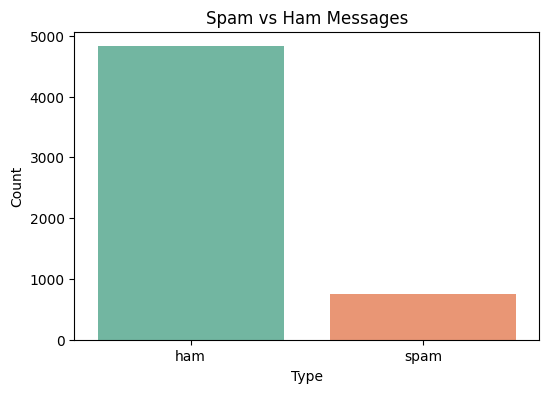

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title("Spam vs Ham Messages")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000, stop_words='english')

X = tfidf.fit_transform(df['message'])
y = df['label_num']

print("✅ TF-IDF Done!")
print("X shape:", X.shape)

✅ TF-IDF Done!
X shape: (5572, 3000)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("✅ Data Split Done!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

✅ Data Split Done!
Training samples: 4457
Testing samples: 1115


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Model 1 - Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_acc = accuracy_score(y_test, nb.predict(X_test))

# Model 2 - Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))

# Model 3 - SVM
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test))

print("✅ All Models Trained!")
print(f"Naive Bayes Accuracy:         {round(nb_acc*100, 2)}%")
print(f"Logistic Regression Accuracy: {round(lr_acc*100, 2)}%")
print(f"SVM Accuracy:                 {round(svm_acc*100, 2)}%")

✅ All Models Trained!
Naive Bayes Accuracy:         98.03%
Logistic Regression Accuracy: 95.52%
SVM Accuracy:                 97.76%


=== Logistic Regression Report ===
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       965
        Spam       0.97      0.69      0.80       150

    accuracy                           0.96      1115
   macro avg       0.96      0.84      0.89      1115
weighted avg       0.96      0.96      0.95      1115



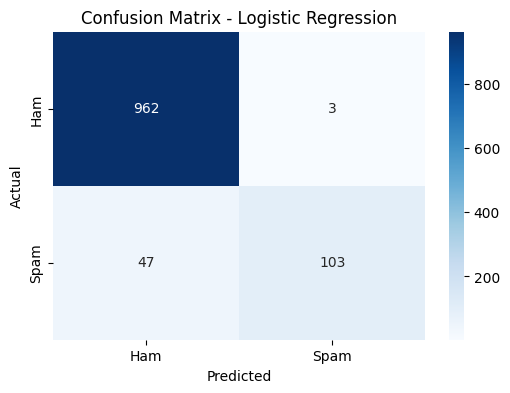

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Detailed Report
print("=== Logistic Regression Report ===")
print(classification_report(y_test, lr.predict(X_test),
      target_names=['Ham', 'Spam']))

# Confusion Matrix Chart
cm = confusion_matrix(y_test, lr.predict(X_test))
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'],
            cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [ ]:
# Test with custom messages
def predict_spam(message):
    msg_tfidf = tfidf.transform([message])
    result = lr.predict(msg_tfidf)
    if result[0] == 1:
        return "SPAM"
    else:
        return "HAM (Not Spam)"

# Try these
print(predict_spam("Win a FREE iPhone now! Click here!"))
print(predict_spam("Hey are you coming to college tomorrow?"))
print(predict_spam("You won Rs.10000 prize! Claim now!"))
print(predict_spam("Please send me the notes after class"))

SPAM
HAM (Not Spam)
SPAM
HAM (Not Spam)
